# Lab 03 — Validasi Dokumen Otomatis

**Modul 5 · Computer Vision**

Notebook ini mendampingi **Materi 3** pada silabus: *validasi dokumen otomatis*.

| Bagian | Isi | Butir materi |
|---|---|---|
| 1 | Membuat berkas masuk (8 dokumen, sebagian bermasalah) | Dasar |
| 2 | Ekstraksi field dari hasil OCR | Ekstraksi |
| 3 | Normalisasi nilai | Normalisasi |
| 4 | Data induk sebagai acuan kebenaran | Pencocokan |
| 5 | Pencocokan nama vendor yang toleran ejaan | Pencocokan |
| 6 | Deteksi pengajuan ganda | Anomali |
| 7 | Mesin aturan tiga lapis | Aturan bisnis |
| 8 | Skoring dan keputusan akhir | Keputusan |
| 9 | Evaluasi terhadap harapan | Metrik |
| 10 | Latihan mandiri | — |

Notebook membuat sendiri seluruh dokumennya. Jika Tesseract tidak terpasang, bagian OCR
otomatis beralih ke **mode simulasi** dengan kesalahan buatan, sehingga seluruh logika
validasi tetap dapat dijalankan dan diuji.

In [1]:
# --- Persiapan ------------------------------------------------------------
import os
import re
import json
import random
import difflib
from datetime import date, datetime

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

np.random.seed(5)
random.seed(5)
KELUARAN = "keluaran_lab03"
os.makedirs(KELUARAN, exist_ok=True)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

OCR_NYATA = False
try:
    import pytesseract
    pytesseract.get_tesseract_version()
    OCR_NYATA = True
except Exception as galat:
    print("Tesseract tidak tersedia ->", type(galat).__name__)
print("Mode OCR:", "MESIN NYATA (Tesseract)" if OCR_NYATA else "SIMULASI")

# Tanggal proses dianggap tetap agar hasil notebook dapat diulang
TANGGAL_PROSES = date(2026, 8, 1)
print("Tanggal proses (acuan pemeriksaan):", TANGGAL_PROSES.isoformat())

Tesseract tidak tersedia -> ModuleNotFoundError
Mode OCR: SIMULASI
Tanggal proses (acuan pemeriksaan): 2026-08-01


## 1. Membuat berkas masuk

Kita siapkan delapan dokumen. Satu bersih, tujuh lainnya membawa satu masalah khas yang
sering ditemui di proses verifikasi. Kolom `harapan` adalah **label acuan**: keputusan
yang seharusnya diambil sistem. Label inilah yang dipakai di bagian 9 untuk menilai
apakah mesin aturan kita sudah benar.

8 dokumen dibuat di folder keluaran_lab03/

kode         no_faktur    total                      masalah harapan
 D01 INV/2026/07/00184 13708500                    tidak ada   LOLOS
 D02 INV/2026/07/00185 13708500     nomor PO tidak terdaftar   TOLAK
 D03 INV/2026/07/00186 16172700        nilai jauh di atas PO   TOLAK
 D04 INV/2026/09/00187 10178700        tanggal di masa depan  TINJAU
 D05 INV/2026/07/00188  7120650 ejaan vendor sedikit berbeda  TINJAU
 D06 INV/2026/07/00189  7378725       vendor tidak terdaftar   TOLAK
 D07 INV/2026/07/00184 13708500              pengajuan ganda   TOLAK
 D08 INV/2026/07/00190  6012870     tanpa stempel pengesahan  TINJAU


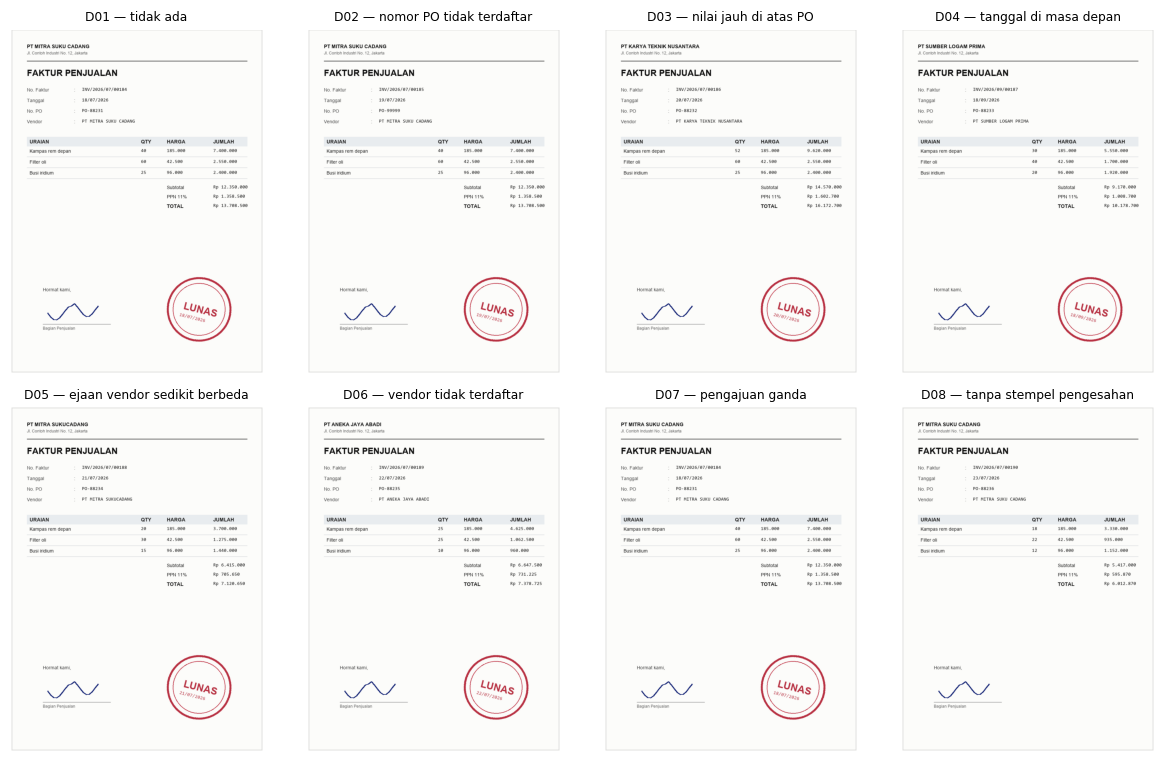

In [2]:
JALUR_FONT = ["/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
              "/Library/Fonts/Arial.ttf", "C:/Windows/Fonts/arial.ttf"]
JALUR_FONT_TEBAL = ["/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
                    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
                    "C:/Windows/Fonts/arialbd.ttf"]
JALUR_FONT_MONO = ["/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
                   "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
                   "C:/Windows/Fonts/consola.ttf"]
HARGA = {"Kampas rem depan": 185000, "Filter oli": 42500, "Busi iridium": 96000}


def ambil_font(ukuran, tebal=False, mono=False):
    for jalur in (JALUR_FONT_MONO if mono else (JALUR_FONT_TEBAL if tebal else JALUR_FONT)):
        if os.path.exists(jalur):
            return ImageFont.truetype(jalur, ukuran)
    return ImageFont.load_default()


def buat_dokumen(no_faktur, tanggal, no_po, vendor, qty=(40, 60, 25), pakai_stempel=True):
    L, T = 760, 1040
    kanvas = Image.new("RGB", (L, T), (252, 252, 250))
    gbr = ImageDraw.Draw(kanvas)
    f_judul, f_tebal = ambil_font(26, tebal=True), ambil_font(15, tebal=True)
    f_biasa, f_kecil, f_mono = ambil_font(14), ambil_font(12), ambil_font(14, mono=True)

    gbr.text((48, 44), vendor, font=f_tebal, fill=(20, 20, 20))
    gbr.text((48, 66), "Jl. Contoh Industri No. 12, Jakarta", font=f_kecil, fill=(90, 90, 90))
    gbr.line([(48, 96), (L - 48, 96)], fill=(60, 60, 60), width=2)
    gbr.text((48, 118), "FAKTUR PENJUALAN", font=f_judul, fill=(15, 15, 15))

    y = 176
    for label, nilai in (("No. Faktur", no_faktur), ("Tanggal", tanggal),
                         ("No. PO", no_po), ("Vendor", vendor)):
        gbr.text((48, y), label, font=f_biasa, fill=(70, 70, 70))
        gbr.text((190, y), ":", font=f_biasa, fill=(70, 70, 70))
        gbr.text((214, y), nilai, font=f_mono, fill=(15, 15, 15))
        y += 32

    y += 22
    gbr.rectangle([(48, y), (L - 48, y + 28)], fill=(232, 236, 239))
    for x, teks in ((56, "URAIAN"), (392, "QTY"), (470, "HARGA"), (610, "JUMLAH")):
        gbr.text((x, y + 6), teks, font=f_tebal, fill=(30, 30, 30))
    y += 28
    subtotal = 0
    for (nama, harga), jumlah_unit in zip(HARGA.items(), qty):
        nilai = jumlah_unit * harga
        subtotal += nilai
        gbr.text((56, y + 7), nama, font=f_biasa, fill=(25, 25, 25))
        gbr.text((392, y + 7), str(jumlah_unit), font=f_mono, fill=(25, 25, 25))
        gbr.text((470, y + 7), f"{harga:,}".replace(",", "."), font=f_mono, fill=(25, 25, 25))
        gbr.text((610, y + 7), f"{nilai:,}".replace(",", "."), font=f_mono, fill=(25, 25, 25))
        gbr.line([(48, y + 32), (L - 48, y + 32)], fill=(200, 205, 210), width=1)
        y += 33

    ppn = int(round(subtotal * 0.11))
    total = subtotal + ppn
    y += 18
    for label, nilai in (("Subtotal", subtotal), ("PPN 11%", ppn), ("TOTAL", total)):
        tebal = label == "TOTAL"
        gbr.text((470, y), label, font=f_tebal if tebal else f_biasa, fill=(25, 25, 25))
        gbr.text((610, y), "Rp " + f"{nilai:,}".replace(",", "."),
                 font=ambil_font(14, tebal=tebal, mono=True), fill=(15, 15, 15))
        y += 28

    gbr.text((96, 780), "Hormat kami,", font=f_biasa, fill=(60, 60, 60))
    titik = [(110 + i * 9, 858 + int(22 * np.sin(i / 1.7)) - (i > 8) * 10) for i in range(18)]
    gbr.line(titik, fill=(25, 40, 120), width=3, joint="curve")
    gbr.line([(96, 892), (300, 892)], fill=(90, 90, 90), width=1)
    gbr.text((96, 898), "Bagian Penjualan", font=f_kecil, fill=(90, 90, 90))

    if pakai_stempel:
        stempel = Image.new("RGBA", (210, 210), (0, 0, 0, 0))
        sd = ImageDraw.Draw(stempel)
        sd.ellipse([(8, 8), (202, 202)], outline=(178, 34, 52, 235), width=6)
        sd.ellipse([(26, 26), (184, 184)], outline=(178, 34, 52, 235), width=2)
        sd.text((58, 88), "LUNAS", font=ambil_font(30, tebal=True), fill=(178, 34, 52, 235))
        sd.text((52, 128), tanggal, font=ambil_font(14, mono=True), fill=(178, 34, 52, 220))
        kanvas.paste(stempel.rotate(-14, resample=Image.BICUBIC), (462, 742),
                     stempel.rotate(-14, resample=Image.BICUBIC))

    gbr.rectangle([(2, 2), (L - 3, T - 3)], outline=(215, 215, 215), width=2)
    citra = cv2.cvtColor(np.array(kanvas), cv2.COLOR_RGB2BGR)
    acuan = {"no_faktur": no_faktur, "tanggal": tanggal, "no_po": no_po, "vendor": vendor,
             "subtotal": subtotal, "ppn": ppn, "total": total, "ada_stempel": pakai_stempel}
    return citra, acuan


AREA_FIELD = (40, 168, 690, 132)
AREA_TOTAL = (452, 462, 268, 96)

SPESIFIKASI = [
    dict(kode="D01", no_faktur="INV/2026/07/00184", tanggal="18/07/2026", no_po="PO-88231",
         vendor="PT MITRA SUKU CADANG", qty=(40, 60, 25), stempel=True,
         masalah="tidak ada", harapan="LOLOS"),
    dict(kode="D02", no_faktur="INV/2026/07/00185", tanggal="19/07/2026", no_po="PO-99999",
         vendor="PT MITRA SUKU CADANG", qty=(40, 60, 25), stempel=True,
         masalah="nomor PO tidak terdaftar", harapan="TOLAK"),
    dict(kode="D03", no_faktur="INV/2026/07/00186", tanggal="20/07/2026", no_po="PO-88232",
         vendor="PT KARYA TEKNIK NUSANTARA", qty=(52, 60, 25), stempel=True,
         masalah="nilai jauh di atas PO", harapan="TOLAK"),
    dict(kode="D04", no_faktur="INV/2026/09/00187", tanggal="18/09/2026", no_po="PO-88233",
         vendor="PT SUMBER LOGAM PRIMA", qty=(30, 40, 20), stempel=True,
         masalah="tanggal di masa depan", harapan="TINJAU"),
    dict(kode="D05", no_faktur="INV/2026/07/00188", tanggal="21/07/2026", no_po="PO-88234",
         vendor="PT MITRA SUKUCADANG", qty=(20, 30, 15), stempel=True,
         masalah="ejaan vendor sedikit berbeda", harapan="TINJAU"),
    dict(kode="D06", no_faktur="INV/2026/07/00189", tanggal="22/07/2026", no_po="PO-88235",
         vendor="PT ANEKA JAYA ABADI", qty=(25, 25, 10), stempel=True,
         masalah="vendor tidak terdaftar", harapan="TOLAK"),
    dict(kode="D07", no_faktur="INV/2026/07/00184", tanggal="18/07/2026", no_po="PO-88231",
         vendor="PT MITRA SUKU CADANG", qty=(40, 60, 25), stempel=True,
         masalah="pengajuan ganda", harapan="TOLAK"),
    dict(kode="D08", no_faktur="INV/2026/07/00190", tanggal="23/07/2026", no_po="PO-88236",
         vendor="PT MITRA SUKU CADANG", qty=(18, 22, 12), stempel=False,
         masalah="tanpa stempel pengesahan", harapan="TINJAU"),
]

berkas_masuk = []
for spesifikasi in SPESIFIKASI:
    citra, acuan = buat_dokumen(spesifikasi["no_faktur"], spesifikasi["tanggal"],
                                spesifikasi["no_po"], spesifikasi["vendor"],
                                spesifikasi["qty"], spesifikasi["stempel"])
    cv2.imwrite(os.path.join(KELUARAN, f'{spesifikasi["kode"]}.png'), citra)
    berkas_masuk.append({"kode": spesifikasi["kode"], "citra": citra, "acuan": acuan,
                         "masalah": spesifikasi["masalah"], "harapan": spesifikasi["harapan"]})

print(f"{len(berkas_masuk)} dokumen dibuat di folder {KELUARAN}/\n")
print(pd.DataFrame([{"kode": b["kode"], "no_faktur": b["acuan"]["no_faktur"],
                     "total": b["acuan"]["total"], "masalah": b["masalah"],
                     "harapan": b["harapan"]} for b in berkas_masuk]).to_string(index=False))

fig, sumbu = plt.subplots(2, 4, figsize=(11, 7))
for ax, b in zip(sumbu.ravel(), berkas_masuk):
    ax.imshow(cv2.cvtColor(b["citra"], cv2.COLOR_BGR2RGB))
    ax.set_title(f'{b["kode"]} — {b["masalah"]}', fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Ekstraksi field dari hasil OCR

OCR menghasilkan **teks mentah**. Yang dibutuhkan proses bisnis adalah **field
terstruktur**. Jembatannya adalah pola (regular expression) yang dirancang mengikuti tata
letak dokumen.

Setiap field diambil beserta **skor keyakinannya**, karena keyakinan itulah yang nanti
menentukan apakah dokumen boleh lolos otomatis.

In [3]:
def _pra_ocr(citra):
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra
    besar = cv2.resize(abu, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    return cv2.threshold(besar, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]


def _teks_acuan_dokumen(acuan):
    # Dipakai mode simulasi: menyusun teks yang seharusnya terbaca dari citra
    rp = lambda n: "Rp " + f"{n:,}".replace(",", ".")
    return (f'No. Faktur : {acuan["no_faktur"]}\n'
            f'Tanggal : {acuan["tanggal"]}\n'
            f'No. PO : {acuan["no_po"]}\n'
            f'Vendor : {acuan["vendor"]}\n'
            f'Subtotal {rp(acuan["subtotal"])}\n'
            f'PPN 11% {rp(acuan["ppn"])}\n'
            f'TOTAL {rp(acuan["total"])}')


def _simulasi_ocr(teks, peluang_galat=0.02, benih=1):
    acak = random.Random(benih)
    tukar = {"0": "O", "O": "0", "1": "l", "5": "S", "8": "B", ".": ","}
    baris_keluar, keyakinan = [], []
    for baris in teks.split("\n"):
        huruf, rusak = [], 0
        for c in baris:
            if c in tukar and acak.random() < peluang_galat:
                huruf.append(tukar[c])
                rusak += 1
            else:
                huruf.append(c)
        baris_keluar.append("".join(huruf))
        keyakinan.append(max(40.0, 96.0 - rusak * 20 - acak.random() * 5))
    return "\n".join(baris_keluar), float(np.mean(keyakinan))


def baca_dokumen(citra, acuan, peluang_galat=0.02, benih=1):
    # Mengembalikan (teks gabungan, keyakinan rata-rata)
    if OCR_NYATA:
        potongan, nilai_keyakinan, bagian = [], [], []
        for (x, y, l, t) in (AREA_FIELD, AREA_TOTAL):
            siap = _pra_ocr(citra[y:y + t, x:x + l])
            bagian.append(pytesseract.image_to_string(siap, config="--psm 6").strip())
            data = pytesseract.image_to_data(siap, config="--psm 6",
                                             output_type=pytesseract.Output.DATAFRAME)
            data = data[data.conf.astype(float) > 0]
            if len(data):
                nilai_keyakinan.append(float(data.conf.astype(float).mean()))
        return "\n".join(bagian), float(np.mean(nilai_keyakinan)) if nilai_keyakinan else 0.0
    return _simulasi_ocr(_teks_acuan_dokumen(acuan), peluang_galat, benih)


POLA = {
    "no_faktur": r"No\.?\s*Faktur\s*[:;]?\s*([A-Z0-9OIl/\.-]{10,})",
    "tanggal": r"Tanggal\s*[:;]?\s*([0-3OIl][0-9OIl][/\.-][01OIl][0-9OIl][/\.-][0-9OIl]{4})",
    "no_po": r"No\.?\s*PO\s*[:;]?\s*([A-Z0-9OIl-]{5,})",
    "vendor": r"Vendor\s*[:;]?\s*([A-Z][A-Z \.]{5,})",
    # Dua catatan penting pada dua pola di bawah ini:
    # 1) jangkar ^ (mode MULTILINE) mencegah kata "Subtotal" ikut cocok dengan "TOTAL";
    # 2) spasi diikutkan ke dalam kelas karakter angka, karena OCR kerap menyisipkan
    #    spasi liar di tengah nominal, misalnya "Rp 13.708 .500".
    "total": r"(?m)^\s*TOTAL\b\D*?([0-9OIl][0-9OIl\.,\s]{4,})\s*$",
    "ppn": r"(?m)^\s*PPN\b[^%]*%?\s*(?:Rp\.?)?\s*([0-9OIl][0-9OIl\.,\s]{4,})\s*$",
}


def ekstrak_field(teks, keyakinan_dokumen):
    hasil = {}
    for nama, pola in POLA.items():
        cocok = re.search(pola, teks, flags=re.IGNORECASE)
        nilai = cocok.group(1).strip() if cocok else None
        # Field yang tidak ditemukan diberi keyakinan 0 - ini pun sebuah sinyal
        hasil[nama] = {"mentah": nilai,
                       "keyakinan": round(keyakinan_dokumen / 100.0, 3) if nilai else 0.0}
    return hasil


contoh = berkas_masuk[0]
teks_contoh, keyakinan_contoh = baca_dokumen(contoh["citra"], contoh["acuan"])
print("--- Teks hasil OCR (D01) ---")
print(teks_contoh)
print(f"\nkeyakinan rata-rata: {keyakinan_contoh:.1f}")
print("\n--- Field terekstraksi ---")
for nama, isi in ekstrak_field(teks_contoh, keyakinan_contoh).items():
    print(f"  {nama:12s}: {str(isi['mentah']):28s} (keyakinan {isi['keyakinan']})")

--- Teks hasil OCR (D01) ---
No. Faktur : INV/2026/07/00184
Tanggal : 18/07/2026
No, PO : PO-88231
Vendor : PT MITRA SUKU CADANG
Subtotal Rp 12.350.000
PPN 11% Rp 1.358.500
TOTAL Rp 13.708.500

keyakinan rata-rata: 90.7

--- Field terekstraksi ---
  no_faktur   : INV/2026/07/00184            (keyakinan 0.907)
  tanggal     : 18/07/2026                   (keyakinan 0.907)
  no_po       : None                         (keyakinan 0.0)
  vendor      : PT MITRA SUKU CADANG         (keyakinan 0.907)
  total       : 13.708.500                   (keyakinan 0.907)
  ppn         : 1.358.500                    (keyakinan 0.907)


## 3. Normalisasi nilai

Teks `"18/07/2026"` dan angka `18 Juli 2026` mengacu pada hal yang sama, tetapi komputer
memperlakukannya sebagai dua hal berbeda. **Normalisasi** menyeragamkan bentuk sebelum
aturan bisnis dijalankan.

Di tahap ini pula kesalahan khas OCR diperbaiki: huruf `O` yang seharusnya angka `0`,
huruf `l` yang seharusnya angka `1`, dan sebagainya. Inilah *pasca-pemrosesan* yang
disebut pada tahap kelima OCR di Materi 2.

In [4]:
GANTI_ANGKA = {"O": "0", "o": "0", "l": "1", "I": "1", "|": "1", "S": "5", "B": "8"}


def bersihkan_angka(teks):
    if teks is None:
        return None
    huruf = [GANTI_ANGKA.get(c, c) for c in teks]
    return "".join(c for c in huruf if c.isdigit())


def ke_rupiah(teks):
    angka = bersihkan_angka(teks)
    return int(angka) if angka else None


def ke_tanggal(teks):
    if teks is None:
        return None
    bersih = "".join(GANTI_ANGKA.get(c, c) for c in teks.strip()).replace(".", "/").replace("-", "/")
    for bentuk in ("%d/%m/%Y", "%Y/%m/%d"):
        try:
            return datetime.strptime(bersih, bentuk).date()
        except ValueError:
            continue
    return None


def rapikan_teks(teks):
    if teks is None:
        return None
    return re.sub(r"\s+", " ", teks).strip().upper()


def normalisasi(field):
    return {
        "no_faktur": rapikan_teks(field["no_faktur"]["mentah"]),
        "tanggal": ke_tanggal(field["tanggal"]["mentah"]),
        "no_po": rapikan_teks(field["no_po"]["mentah"]),
        "vendor": rapikan_teks(field["vendor"]["mentah"]),
        "total": ke_rupiah(field["total"]["mentah"]),
        "ppn": ke_rupiah(field["ppn"]["mentah"]),
    }


print("Contoh normalisasi:")
for masukan, fungsi in ((" 18/O7/2O26 ", ke_tanggal), ("Rp 13.708.5OO", ke_rupiah),
                        ("  pt mitra   suku cadang ", rapikan_teks)):
    print(f"  {masukan!r:26s} -> {fungsi(masukan)!r}")

nilai_contoh = normalisasi(ekstrak_field(teks_contoh, keyakinan_contoh))
print("\nHasil normalisasi D01:")
for kunci, nilai in nilai_contoh.items():
    print(f"  {kunci:12s}: {nilai!r}")

Contoh normalisasi:
  ' 18/O7/2O26 '             -> datetime.date(2026, 7, 18)
  'Rp 13.708.5OO'            -> 13708500
  '  pt mitra   suku cadang ' -> 'PT MITRA SUKU CADANG'

Hasil normalisasi D01:
  no_faktur   : 'INV/2026/07/00184'
  tanggal     : datetime.date(2026, 7, 18)
  no_po       : None
  vendor      : 'PT MITRA SUKU CADANG'
  total       : 13708500
  ppn         : 1358500


## 4. Data induk sebagai acuan kebenaran

Validasi paling bernilai bukan memeriksa bentuk, melainkan **mencocokkan dokumen dengan
data yang sudah ada di sistem**: apakah nomor PO-nya benar ada, apakah vendornya
terdaftar, apakah nilainya sesuai pemesanan.

Tanpa data induk yang bersih, otomasi validasi hanya mampu memeriksa format.

In [5]:
def hitung_total(qty):
    subtotal = sum(j * h for j, h in zip(qty, HARGA.values()))
    return subtotal + int(round(subtotal * 0.11))


MASTER_PO = pd.DataFrame([
    {"no_po": "PO-88231", "vendor": "PT MITRA SUKU CADANG", "nilai_po": hitung_total((40, 60, 25)), "status": "terbuka"},
    {"no_po": "PO-88232", "vendor": "PT KARYA TEKNIK NUSANTARA", "nilai_po": hitung_total((40, 60, 25)), "status": "terbuka"},
    {"no_po": "PO-88233", "vendor": "PT SUMBER LOGAM PRIMA", "nilai_po": hitung_total((30, 40, 20)), "status": "terbuka"},
    {"no_po": "PO-88234", "vendor": "PT MITRA SUKU CADANG", "nilai_po": hitung_total((20, 30, 15)), "status": "terbuka"},
    {"no_po": "PO-88235", "vendor": "PT KARYA TEKNIK NUSANTARA", "nilai_po": hitung_total((25, 25, 10)), "status": "terbuka"},
    {"no_po": "PO-88236", "vendor": "PT MITRA SUKU CADANG", "nilai_po": hitung_total((18, 22, 12)), "status": "terbuka"},
]).set_index("no_po")

MASTER_VENDOR = ["PT MITRA SUKU CADANG", "PT KARYA TEKNIK NUSANTARA",
                 "PT SUMBER LOGAM PRIMA", "PT BINTANG OTOPARTS"]

TOLERANSI_NILAI = 0.02  # selisih nilai faktur terhadap PO yang masih dapat diterima
AMBANG_KEYAKINAN = 0.80  # keyakinan OCR minimum untuk lolos otomatis
AMBANG_VENDOR = 0.88     # kemiripan nama vendor minimum agar dianggap cocok

print("Data induk PO:")
print(MASTER_PO.to_string())
print("\nVendor terdaftar:", ", ".join(MASTER_VENDOR))

Data induk PO:
                             vendor  nilai_po   status
no_po                                                 
PO-88231       PT MITRA SUKU CADANG  13708500  terbuka
PO-88232  PT KARYA TEKNIK NUSANTARA  13708500  terbuka
PO-88233      PT SUMBER LOGAM PRIMA  10178700  terbuka
PO-88234       PT MITRA SUKU CADANG   7120650  terbuka
PO-88235  PT KARYA TEKNIK NUSANTARA   7378725  terbuka
PO-88236       PT MITRA SUKU CADANG   6012870  terbuka

Vendor terdaftar: PT MITRA SUKU CADANG, PT KARYA TEKNIK NUSANTARA, PT SUMBER LOGAM PRIMA, PT BINTANG OTOPARTS


## 5. Pencocokan nama vendor yang toleran ejaan

Nama vendor jarang tertulis persis sama: ada yang memakai titik, ada yang menyingkat,
dan OCR pun bisa keliru satu huruf. Perbandingan `==` terlalu kaku.

`difflib.SequenceMatcher` memberi skor kemiripan 0–1. Ambang kemiripan menentukan sikap
sistem: sangat mirip berarti cocok, agak mirip berarti perlu ditinjau manusia, dan jauh
berbeda berarti vendor tidak dikenal.

In [6]:
def kemiripan(a, b):
    return difflib.SequenceMatcher(None, a or "", b or "").ratio()


def cocokkan_vendor(nama, daftar=MASTER_VENDOR):
    if not nama:
        return None, 0.0
    skor = [(kandidat, kemiripan(nama, kandidat)) for kandidat in daftar]
    return max(skor, key=lambda p: p[1])


uji_vendor = ["PT MITRA SUKU CADANG", "PT MITRA SUKUCADANG", "PT. MITRA SUKU CADANG",
              "PT MITRA SUKU CADNAG", "PT ANEKA JAYA ABADI"]
print(f'{"nama pada dokumen":26s} {"padanan terdekat":28s} skor   putusan')
for nama in uji_vendor:
    padanan, skor = cocokkan_vendor(nama)
    if nama == padanan:
        putusan = "cocok persis -> lolos"
    elif skor >= AMBANG_VENDOR:
        putusan = "mirip -> perlu tinjauan"
    else:
        putusan = "tidak dikenal -> tolak"
    print(f"{nama:26s} {padanan:28s} {skor:.3f}  {putusan}")

nama pada dokumen          padanan terdekat             skor   putusan
PT MITRA SUKU CADANG       PT MITRA SUKU CADANG         1.000  cocok persis -> lolos
PT MITRA SUKUCADANG        PT MITRA SUKU CADANG         0.974  mirip -> perlu tinjauan
PT. MITRA SUKU CADANG      PT MITRA SUKU CADANG         0.976  mirip -> perlu tinjauan
PT MITRA SUKU CADNAG       PT MITRA SUKU CADANG         0.950  mirip -> perlu tinjauan
PT ANEKA JAYA ABADI        PT KARYA TEKNIK NUSANTARA    0.455  tidak dikenal -> tolak


## 6. Deteksi pengajuan ganda

Dua lapis pemeriksaan dipakai bersama:

1. **Kunci dokumen** — kombinasi nomor faktur dan vendor. Menangkap dokumen sama yang
   diajukan ulang, meski citranya berbeda (misal difoto ulang).
2. **Sidik jari citra (*dHash*)** — merangkum citra menjadi 64 bit berdasarkan arah
   perubahan terang-gelap antar piksel bertetangga. Menangkap citra yang identik atau
   nyaris identik, meski nomornya sudah diubah.

Jarak Hamming antar sidik jari mengukur seberapa mirip dua citra: 0 berarti identik.

> **Keterbatasan yang wajib diketahui.** Dua faktur dari vendor yang sama secara visual
> nyaris identik — yang berbeda hanya beberapa karakter kecil. Sidik jari citra beresolusi
> rendah (8x8) akan menganggap keduanya sama dan menimbulkan tuduhan duplikasi palsu.
> Karena itu di notebook ini sidik jari dibuat 32x32 (1024 bit), ambangnya diperketat
> menjadi "harus identik", dan aturannya **tidak dijadikan kritis**. Pemeriksaan duplikasi
> yang menentukan tetap **kunci dokumen** (nomor faktur + vendor) pada aturan E07.
> Sidik jari citra hanyalah sinyal pendukung.

Sidik jari citra (dHash 32x32 = 1024 bit, 16 digit heksadesimal pertama):
  D01: 800000008a6000009 ...
  D02: 800000008a6000009 ...
  D03: 80000000995800009 ...
  D04: 800000008c6000009 ...
  D05: 800000008a6000009 ...
  D06: 800000008ac000009 ...
  D07: 800000008a6000009 ...
  D08: 800000008a6000009 ...


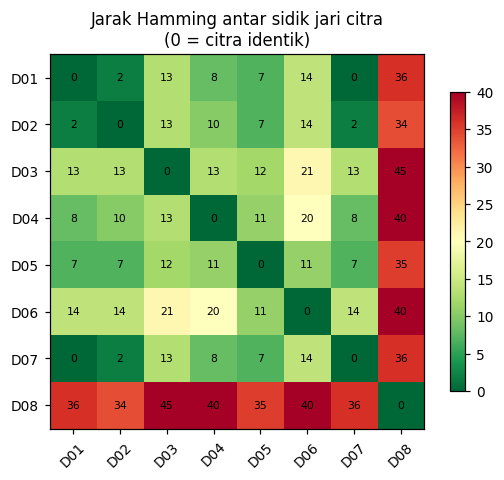

In [7]:
def sidik_citra(citra, sisi=32):
    # dHash: bandingkan setiap piksel dengan tetangga kanannya
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra
    kecil = cv2.resize(abu, (sisi + 1, sisi), interpolation=cv2.INTER_AREA)
    bit = kecil[:, 1:] > kecil[:, :-1]
    nilai = 0
    for b in bit.flatten():
        nilai = (nilai << 1) | int(b)
    return nilai


def jarak_hamming(a, b):
    return bin(a ^ b).count("1")


sidik = {b["kode"]: sidik_citra(b["citra"]) for b in berkas_masuk}
print("Sidik jari citra (dHash 32x32 = 1024 bit, 16 digit heksadesimal pertama):")
for kode, nilai in sidik.items():
    print(f"  {kode}: {nilai:0256x}"[:24], "...")

kode_urut = list(sidik)
matriks = np.array([[jarak_hamming(sidik[a], sidik[b]) for b in kode_urut] for a in kode_urut])
fig, ax = plt.subplots(figsize=(5.4, 4.4))
peta = ax.imshow(matriks, cmap="RdYlGn_r", vmin=0, vmax=40)
ax.set_xticks(range(len(kode_urut)), kode_urut, rotation=45)
ax.set_yticks(range(len(kode_urut)), kode_urut)
for i in range(len(kode_urut)):
    for j in range(len(kode_urut)):
        ax.text(j, i, matriks[i, j], ha="center", va="center", fontsize=7)
ax.set_title("Jarak Hamming antar sidik jari citra\n(0 = citra identik)")
plt.colorbar(peta, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 7. Mesin aturan tiga lapis

Setiap aturan ditulis sebagai satu fungsi kecil yang mengembalikan `(lolos, pesan)`.
Bentuk seperti ini membuat aturan mudah dibaca pemilik proses, mudah diuji satu per satu,
dan mudah ditambah tanpa mengubah mesin utamanya.

Tiga lapis mengikuti slide Materi 3:

| Lapis | Pertanyaan | Contoh |
|---|---|---|
| 1 — Format | Apakah bentuk nilainya masuk akal? | pola nomor faktur, tanggal valid |
| 2 — Konsistensi internal | Apakah isi dokumen saling cocok? | PPN sesuai tarif terhadap total |
| 3 — Kecocokan eksternal | Apakah cocok dengan sistem? | PO terdaftar, nilai sesuai, tidak ganda |

In [8]:
POLA_FAKTUR = re.compile(r"^INV/\d{4}/\d{2}/\d{5}$")
POLA_PO = re.compile(r"^PO-\d{5}$")


def daftar_aturan(riwayat_kunci, riwayat_sidik):
    # riwayat_* berisi dokumen yang sudah diproses sebelumnya (untuk uji duplikasi)

    def a_format_faktur(d, k):
        if not d["no_faktur"]:
            return False, "nomor faktur tidak terbaca"
        return bool(POLA_FAKTUR.match(d["no_faktur"])), f'pola nomor faktur: {d["no_faktur"]}'

    def a_format_po(d, k):
        if not d["no_po"]:
            return False, "nomor PO tidak terbaca"
        return bool(POLA_PO.match(d["no_po"])), f'pola nomor PO: {d["no_po"]}'

    def a_tanggal_valid(d, k):
        return d["tanggal"] is not None, "tanggal tidak terbaca atau tidak valid"

    def a_tanggal_wajar(d, k):
        if d["tanggal"] is None:
            return False, "tanggal tidak terbaca"
        if d["tanggal"] > TANGGAL_PROSES:
            return False, f'tanggal {d["tanggal"]} berada di masa depan'
        if (TANGGAL_PROSES - d["tanggal"]).days > 120:
            return False, f'dokumen lebih tua dari 120 hari ({d["tanggal"]})'
        return True, "tanggal berada dalam periode wajar"

    def a_total_terbaca(d, k):
        return bool(d["total"]), "nilai total tidak terbaca"

    def a_ppn_konsisten(d, k):
        if not d["total"] or not d["ppn"]:
            return False, "total atau PPN tidak terbaca"
        dasar = d["total"] - d["ppn"]
        harapan = int(round(dasar * 0.11))
        selisih = abs(harapan - d["ppn"]) / max(1, harapan)
        return selisih <= 0.01, f'PPN menyimpang {selisih:.1%} dari tarif 11%'

    def a_po_terdaftar(d, k):
        if d["no_po"] not in MASTER_PO.index:
            return False, f'nomor PO {d["no_po"]} tidak ada di data induk'
        return True, "PO ditemukan di data induk"

    def a_po_terbuka(d, k):
        if d["no_po"] not in MASTER_PO.index:
            return False, "PO tidak ditemukan"
        status = MASTER_PO.loc[d["no_po"], "status"]
        return status == "terbuka", f'status PO: {status}'

    def a_vendor_terdaftar(d, k):
        padanan, skor = cocokkan_vendor(d["vendor"])
        k["vendor_padanan"], k["vendor_skor"] = padanan, round(skor, 3)
        return skor >= AMBANG_VENDOR, f'vendor terdekat "{padanan}" (kemiripan {skor:.2f})'

    def a_vendor_persis(d, k):
        skor = k.get("vendor_skor", 0.0)
        persis = d["vendor"] is not None and d["vendor"] == k.get("vendor_padanan")
        return persis, (f'ejaan vendor tidak persis sama dengan data induk '
                        f'(kemiripan {skor:.2f})')

    def a_vendor_sesuai_po(d, k):
        if d["no_po"] not in MASTER_PO.index:
            return False, "PO tidak ditemukan"
        vendor_po = MASTER_PO.loc[d["no_po"], "vendor"]
        skor = kemiripan(d["vendor"], vendor_po)
        return skor >= AMBANG_VENDOR, f'vendor faktur tidak sesuai vendor PO ({vendor_po})'

    def a_nilai_sesuai_po(d, k):
        if d["no_po"] not in MASTER_PO.index or not d["total"]:
            return False, "PO atau nilai total tidak tersedia"
        nilai_po = int(MASTER_PO.loc[d["no_po"], "nilai_po"])
        selisih = abs(d["total"] - nilai_po) / max(1, nilai_po)
        k["selisih_po"] = round(selisih, 4)
        return selisih <= TOLERANSI_NILAI, (f'selisih {selisih:.1%} terhadap nilai PO '
                                            f'(faktur {d["total"]:,} vs PO {nilai_po:,})')

    def a_tidak_ganda_kunci(d, k):
        kunci = (d["no_faktur"], k.get("vendor_padanan"))
        k["kunci"] = kunci
        return kunci not in riwayat_kunci, f'nomor faktur {d["no_faktur"]} sudah pernah diproses'

    def a_tidak_ganda_citra(d, k):
        for kode_lama, sidik_lama in riwayat_sidik.items():
            if jarak_hamming(k["sidik"], sidik_lama) == 0:
                return False, f'citra nyaris identik dengan dokumen {kode_lama}'
        return True, "tidak ada citra kembar di riwayat"

    def a_ada_pengesahan(d, k):
        return k["ada_stempel"], "stempel pengesahan tidak terdeteksi"

    def a_keyakinan_cukup(d, k):
        return k["keyakinan"] >= AMBANG_KEYAKINAN, (
            f'keyakinan pembacaan {k["keyakinan"]:.2f} di bawah ambang {AMBANG_KEYAKINAN}')

    return [
        {"kode": "F01", "lapis": 1, "kritis": True, "uji": a_format_faktur},
        {"kode": "F02", "lapis": 1, "kritis": True, "uji": a_format_po},
        {"kode": "F03", "lapis": 1, "kritis": True, "uji": a_tanggal_valid},
        {"kode": "F04", "lapis": 1, "kritis": False, "uji": a_tanggal_wajar},
        {"kode": "F05", "lapis": 1, "kritis": True, "uji": a_total_terbaca},
        {"kode": "K01", "lapis": 2, "kritis": False, "uji": a_ppn_konsisten},
        {"kode": "K02", "lapis": 2, "kritis": False, "uji": a_ada_pengesahan},
        {"kode": "K03", "lapis": 2, "kritis": False, "uji": a_keyakinan_cukup},
        {"kode": "E01", "lapis": 3, "kritis": True, "uji": a_po_terdaftar},
        {"kode": "E02", "lapis": 3, "kritis": True, "uji": a_po_terbuka},
        {"kode": "E03", "lapis": 3, "kritis": True, "uji": a_vendor_terdaftar},
        {"kode": "E04", "lapis": 3, "kritis": False, "uji": a_vendor_persis},
        {"kode": "E05", "lapis": 3, "kritis": True, "uji": a_vendor_sesuai_po},
        {"kode": "E06", "lapis": 3, "kritis": True, "uji": a_nilai_sesuai_po},
        {"kode": "E07", "lapis": 3, "kritis": True, "uji": a_tidak_ganda_kunci},
        {"kode": "E08", "lapis": 3, "kritis": False, "uji": a_tidak_ganda_citra},
    ]


print(f"Jumlah aturan: {len(daftar_aturan(set(), {}))}")
print(pd.DataFrame([{k: v for k, v in a.items() if k != 'uji'}
                    for a in daftar_aturan(set(), {})]).to_string(index=False))

Jumlah aturan: 16
kode  lapis  kritis
 F01      1    True
 F02      1    True
 F03      1    True
 F04      1   False
 F05      1    True
 K01      2   False
 K02      2   False
 K03      2   False
 E01      3    True
 E02      3    True
 E03      3    True
 E04      3   False
 E05      3    True
 E06      3    True
 E07      3    True
 E08      3   False


## 8. Skoring dan keputusan akhir

Keputusan disusun dari dua bahan: **hasil aturan** dan **keyakinan pembacaan**.

- Ada aturan **kritis** yang gagal → `TOLAK`
- Ada aturan tidak kritis yang gagal, atau keyakinan di bawah ambang → `TINJAU`
- Semua terpenuhi → `LOLOS`

Susunan ini sengaja konservatif: mesin hanya meloloskan dokumen yang bersih sempurna.
Menaikkan tingkat otomatis sebaiknya dilakukan bertahap, setelah ada bukti dari
pemantauan bahwa kesalahan tetap rendah.

In [9]:
def periksa_dokumen(berkas, riwayat_kunci, riwayat_sidik):
    teks, keyakinan = baca_dokumen(berkas["citra"], berkas["acuan"],
                                   peluang_galat=0.02, benih=hash(berkas["kode"]) % 1000)
    field = ekstrak_field(teks, keyakinan)
    nilai = normalisasi(field)

    konteks = {"keyakinan": keyakinan / 100.0,
               "sidik": sidik_citra(berkas["citra"]),
               "ada_stempel": bool(berkas["acuan"]["ada_stempel"])}

    pelanggaran, lolos_semua = [], True
    for aturan in daftar_aturan(riwayat_kunci, riwayat_sidik):
        try:
            lolos, pesan = aturan["uji"](nilai, konteks)
        except Exception as galat:
            lolos, pesan = False, f"aturan gagal dijalankan: {galat}"
        if not lolos:
            lolos_semua = False
            pelanggaran.append({"kode": aturan["kode"], "lapis": aturan["lapis"],
                                "kritis": aturan["kritis"], "pesan": pesan})

    ada_kritis = any(p["kritis"] for p in pelanggaran)
    if ada_kritis:
        keputusan = "TOLAK"
    elif pelanggaran:
        keputusan = "TINJAU"
    else:
        keputusan = "LOLOS"

    skor = round(konteks["keyakinan"] * (1 - 0.12 * len(pelanggaran)), 3)
    return {"kode": berkas["kode"], "keputusan": keputusan, "skor": max(0.0, skor),
            "keyakinan": round(konteks["keyakinan"], 3), "nilai": nilai,
            "pelanggaran": pelanggaran, "konteks": konteks}


riwayat_kunci, riwayat_sidik, hasil_periksa = set(), {}, []
for berkas in berkas_masuk:
    hasil = periksa_dokumen(berkas, riwayat_kunci, riwayat_sidik)
    hasil_periksa.append(hasil)
    # Dokumen yang tidak ditolak masuk riwayat, sehingga pengajuan berikutnya terdeteksi ganda
    if hasil["keputusan"] != "TOLAK":
        riwayat_kunci.add(hasil["konteks"].get("kunci", (hasil["nilai"]["no_faktur"],
                                                         hasil["konteks"].get("vendor_padanan"))))
        riwayat_sidik[hasil["kode"]] = hasil["konteks"]["sidik"]

ringkasan = pd.DataFrame([{
    "kode": h["kode"],
    "keputusan": h["keputusan"],
    "skor": h["skor"],
    "keyakinan": h["keyakinan"],
    "jml_pelanggaran": len(h["pelanggaran"]),
    "pelanggaran": ", ".join(p["kode"] for p in h["pelanggaran"]) or "-",
} for h in hasil_periksa])
ringkasan

,kode,keputusan,skor,keyakinan,jml_pelanggaran,pelanggaran
0,D01,TOLAK,0.365,0.912,5,"F02, E01, E02, E05, E06"
1,D02,TOLAK,0.484,0.931,4,"E01, E02, E05, E06"
2,D03,TOLAK,0.664,0.874,2,"F01, E06"
3,D04,TINJAU,0.818,0.930,1,F04
4,D05,TOLAK,0.254,0.908,6,"F02, E01, E02, E04, E05, E06"
5,D06,TOLAK,0.605,0.945,3,"E03, E04, E05"
6,D07,LOLOS,0.841,0.841,0,-
7,D08,TINJAU,0.827,0.939,1,K02


In [10]:
# Rincian alasan per dokumen - inilah yang ditampilkan kepada petugas peninjau
for h in hasil_periksa:
    print(f'{h["kode"]}  ->  {h["keputusan"]}  (skor {h["skor"]:.2f})')
    if not h["pelanggaran"]:
        print("     seluruh aturan terpenuhi")
    for p in h["pelanggaran"]:
        tanda = "KRITIS " if p["kritis"] else "catatan"
        print(f'     [{tanda}] lapis {p["lapis"]} {p["kode"]}: {p["pesan"]}')
    print()

D01  ->  TOLAK  (skor 0.36)
     [KRITIS ] lapis 1 F02: pola nomor PO: PO-8B231
     [KRITIS ] lapis 3 E01: nomor PO PO-8B231 tidak ada di data induk
     [KRITIS ] lapis 3 E02: PO tidak ditemukan
     [KRITIS ] lapis 3 E05: PO tidak ditemukan
     [KRITIS ] lapis 3 E06: PO atau nilai total tidak tersedia

D02  ->  TOLAK  (skor 0.48)
     [KRITIS ] lapis 3 E01: nomor PO PO-99999 tidak ada di data induk
     [KRITIS ] lapis 3 E02: PO tidak ditemukan
     [KRITIS ] lapis 3 E05: PO tidak ditemukan
     [KRITIS ] lapis 3 E06: PO atau nilai total tidak tersedia

D03  ->  TOLAK  (skor 0.66)
     [KRITIS ] lapis 1 F01: pola nomor faktur: INV/2026/O7/00186
     [KRITIS ] lapis 3 E06: selisih 18.0% terhadap nilai PO (faktur 16,172,700 vs PO 13,708,500)

D04  ->  TINJAU  (skor 0.82)
     [catatan] lapis 1 F04: tanggal 2026-09-18 berada di masa depan

D05  ->  TOLAK  (skor 0.25)
     [KRITIS ] lapis 1 F02: pola nomor PO: PO-B8234
     [KRITIS ] lapis 3 E01: nomor PO PO-B8234 tidak ada di data ind

## 9. Evaluasi terhadap harapan

Mesin aturan pun perlu diuji. Kita bandingkan keputusan sistem dengan kolom `harapan`
yang sudah ditetapkan di bagian 1 — persis seperti menguji model dengan data berlabel.

Bila ada baris yang tidak cocok, yang perlu diperbaiki biasanya bukan modelnya,
melainkan **rumusan aturan atau ambangnya**.

kode                      masalah harapan keputusan  sesuai                  pelanggaran
 D01                    tidak ada   LOLOS     TOLAK   False      F02, E01, E02, E05, E06
 D02     nomor PO tidak terdaftar   TOLAK     TOLAK    True           E01, E02, E05, E06
 D03        nilai jauh di atas PO   TOLAK     TOLAK    True                     F01, E06
 D04        tanggal di masa depan  TINJAU    TINJAU    True                          F04
 D05 ejaan vendor sedikit berbeda  TINJAU     TOLAK   False F02, E01, E02, E04, E05, E06
 D06       vendor tidak terdaftar   TOLAK     TOLAK    True                E03, E04, E05
 D07              pengajuan ganda   TOLAK     LOLOS   False                            -
 D08     tanpa stempel pengesahan  TINJAU    TINJAU    True                          K02

Kesesuaian: 5 dari 8 dokumen

Matriks kebingungan:
keputusan  LOLOS  TINJAU  TOLAK
harapan                        
LOLOS          0       0      1
TINJAU         0       2      1
TOLAK          1   

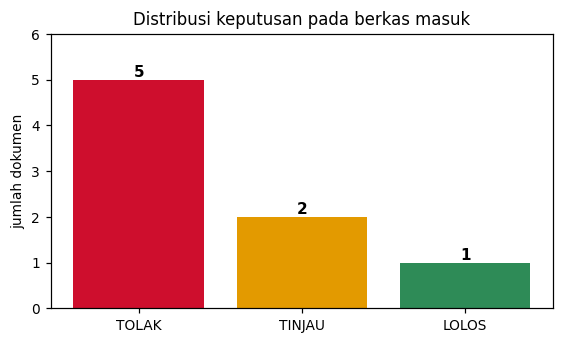

In [11]:
evaluasi = ringkasan.merge(
    pd.DataFrame([{"kode": b["kode"], "masalah": b["masalah"], "harapan": b["harapan"]}
                  for b in berkas_masuk]), on="kode")
evaluasi["sesuai"] = evaluasi["keputusan"] == evaluasi["harapan"]
print(evaluasi[["kode", "masalah", "harapan", "keputusan", "sesuai", "pelanggaran"]].to_string(index=False))
print(f'\nKesesuaian: {evaluasi["sesuai"].sum()} dari {len(evaluasi)} dokumen')

matriks_bingung = pd.crosstab(evaluasi["harapan"], evaluasi["keputusan"],
                              rownames=["harapan"], colnames=["keputusan"])
print("\nMatriks kebingungan:")
print(matriks_bingung.to_string())

hitung = ringkasan["keputusan"].value_counts()
fig, ax = plt.subplots(figsize=(5.2, 3.2))
warna_peta = {"LOLOS": "#2E8B57", "TINJAU": "#E39A00", "TOLAK": "#CE0E2D"}
ax.bar(hitung.index, hitung.values, color=[warna_peta.get(k, "#7C97A6") for k in hitung.index])
for i, (nama, jumlah) in enumerate(hitung.items()):
    ax.text(i, jumlah + 0.06, str(jumlah), ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("jumlah dokumen")
ax.set_title("Distribusi keputusan pada berkas masuk")
ax.set_ylim(0, max(hitung.values) + 1)
plt.tight_layout()
plt.show()

In [12]:
# Simpan hasil pemeriksaan agar dapat dipakai kembali oleh Lab 04
def ke_json(objek):
    if isinstance(objek, (date, datetime)):
        return objek.isoformat()
    if isinstance(objek, (np.integer,)):
        return int(objek)
    if isinstance(objek, (np.floating,)):
        return float(objek)
    return str(objek)


berkas_hasil = os.path.join(KELUARAN, "hasil_validasi.json")
with open(berkas_hasil, "w", encoding="utf-8") as f:
    json.dump([{k: v for k, v in h.items() if k != "konteks"} for h in hasil_periksa],
              f, ensure_ascii=False, indent=2, default=ke_json)
print("Hasil validasi disimpan ke", os.path.abspath(berkas_hasil))
print(open(berkas_hasil, encoding="utf-8").read()[:700], "...")

Hasil validasi disimpan ke e:\Paket_Latihan_ML_AHM\Modul 5\keluaran_lab03\hasil_validasi.json
[
  {
    "kode": "D01",
    "keputusan": "TOLAK",
    "skor": 0.365,
    "keyakinan": 0.912,
    "nilai": {
      "no_faktur": "INV/2026/07/00184",
      "tanggal": "2026-07-18",
      "no_po": "PO-8B231",
      "vendor": "PT MITRA SUKU CADANG",
      "total": 13708500,
      "ppn": 1358500
    },
    "pelanggaran": [
      {
        "kode": "F02",
        "lapis": 1,
        "kritis": true,
        "pesan": "pola nomor PO: PO-8B231"
      },
      {
        "kode": "E01",
        "lapis": 3,
        "kritis": true,
        "pesan": "nomor PO PO-8B231 tidak ada di data induk"
      },
      {
        "kode": "E02",
        "lapis": 3,
        "kritis": true,
        "pesan": "PO tidak ditem ...


## 10. Latihan mandiri

1. **Aturan baru.** Tambahkan aturan lapis 2 bernama `K04` yang memeriksa bahwa nilai
   total minimal sama dengan PPN dikali sembilan (konsistensi kasar tarif 11%). Uji pada
   seluruh berkas masuk.
2. **Menggeser ambang.** Naikkan `TOLERANSI_NILAI` menjadi 0,10. Dokumen mana yang
   berubah keputusannya, dan risiko apa yang muncul bagi pencatatan keuangan?
3. **Kasus baru.** Tambahkan dokumen D09 dengan nomor faktur berformat salah
   (misalnya `INVOICE-2026-07-1`) dan pastikan sistem menolaknya lewat aturan F01.
4. **Ambang vendor.** Turunkan `AMBANG_VENDOR` menjadi 0,70, lalu jalankan ulang. Apakah
   D06 masih tertahan? Apa yang bisa Anda simpulkan tentang risiko ambang yang terlalu
   longgar?
5. **Tinjauan bersama.** Pilih satu jenis dokumen di unit kerja Anda, lalu tuliskan
   sepuluh aturan validasinya dalam format tabel `kode | lapis | kritis | penjelasan`.
   Diskusikan dengan pemilik prosesnya — ini latihan paling bernilai dari modul ini.

In [13]:
# Kerangka jawaban latihan 1 - silakan lengkapi lalu sisipkan ke daftar_aturan()
def a_total_wajar_terhadap_ppn(d, k):
    if not d["total"] or not d["ppn"]:
        return False, "total atau PPN tidak terbaca"
    # TODO: kembalikan (True, pesan) bila total >= ppn * 9, selain itu (False, pesan)
    return True, "belum diimplementasikan"


for h in hasil_periksa[:3]:
    print(h["kode"], a_total_wajar_terhadap_ppn(h["nilai"], h["konteks"]))

D01 (True, 'belum diimplementasikan')
D02 (True, 'belum diimplementasikan')
D03 (True, 'belum diimplementasikan')


## Ringkasan

- Validasi otomatis berjalan dalam empat langkah: **ekstraksi → normalisasi → aturan →
  keputusan**, dan setiap langkah meninggalkan jejak yang dapat diaudit.
- Aturan yang ditulis sebagai fungsi kecil mudah dibaca pemilik proses, mudah diuji, dan
  mudah ditambah. Ini penting karena aturan bisnis pasti berubah.
- Nilai terbesar ada di **lapis 3**: mencocokkan dokumen dengan data induk dan riwayat.
  Karena itu kebersihan data induk menentukan keberhasilan otomasi.
- Pencocokan yang toleran ejaan mencegah penolakan berlebihan, tetapi ambangnya harus
  dipilih sadar risiko.
- Mesin aturan wajib diuji terhadap label harapan, sama seperti model diuji terhadap data
  berlabel.

**Lanjut ke:** `04_integrasi_alur_kerja_digital.ipynb` — menyambungkan seluruh hasil ini
ke sistem bisnis.